# Apple Health Export Parser

Streams through a large `export.xml` file (Apple Health) using `iterparse` so the whole file is never loaded into memory at once. Extracts `<Record>` elements into a pandas DataFrame.

**How it works:** `ET.iterparse` fires an event each time a tag closes. We grab the attributes we want, then call `elem.clear()` to free that element's memory immediately — this keeps RAM usage flat even on a 766 MB+ file.

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path

# >>> EDIT THIS to point at your file <<<
XML_PATH = "Johan_Jul_26.xml"

assert Path(XML_PATH).exists(), f"File not found: {XML_PATH}"
print(f"File size: {Path(XML_PATH).stat().st_size / 1_000_000:.1f} MB")

File size: 803.5 MB


## Step 1: Filter to the record types you care about

Apple Health uses long identifiers like `HKQuantityTypeIdentifierHeartRate`, `HKQuantityTypeIdentifierBodyMass`, `HKQuantityTypeIdentifierStepCount`, etc.

Leave `TYPES_TO_KEEP = None` to keep every record type (bigger DataFrame, slower), or list specific ones to keep the run fast and memory-light.

In [2]:
# Example: only keep heart rate and body mass records
TYPES_TO_KEEP = {
    "HKQuantityTypeIdentifierHeartRate",
    "HKQuantityTypeIdentifierBodyMass",
    "HKQuantityTypeIdentifierHeartRateVariabilitySDNN",   # HRV (SDNN) — chronic inflammation tends to suppress this
    "HKQuantityTypeIdentifierRestingHeartRate",           # tends to rise with systemic inflammation
    "HKQuantityTypeIdentifierRespiratoryRate",
    "HKQuantityTypeIdentifierOxygenSaturation",
    "HKQuantityTypeIdentifierBodyTemperature",
    "HKCategoryTypeIdentifierSleepAnalysis",              # poor sleep both reflects and drives inflammation
}


# To keep everything instead, uncomment:
# TYPES_TO_KEEP = None

## Step 2: (Optional) First pass — see what record types exist and how many of each

Useful for deciding what to put in `TYPES_TO_KEEP` above. This pass is fast because it doesn't collect attributes, just counts.

In [3]:
from collections import Counter

type_counts = Counter()

context = ET.iterparse(XML_PATH, events=("end",))
for event, elem in context:
    if elem.tag == "Record":
        type_counts[elem.get("type")] += 1
    elem.clear()  # free memory immediately

for rtype, count in type_counts.most_common():
    print(f"{count:>8}  {rtype}")

  292870  HKQuantityTypeIdentifierHeartRate
  269823  HKQuantityTypeIdentifierPhysicalEffort
  258730  HKQuantityTypeIdentifierActiveEnergyBurned
  198164  HKQuantityTypeIdentifierBasalEnergyBurned
  164869  HKQuantityTypeIdentifierDistanceWalkingRunning
  115062  HKQuantityTypeIdentifierStepCount
   93769  HKQuantityTypeIdentifierHeadphoneAudioExposure
   78037  HKQuantityTypeIdentifierWalkingSpeed
   78036  HKQuantityTypeIdentifierWalkingStepLength
   68760  HKQuantityTypeIdentifierWalkingDoubleSupportPercentage
   40776  HKQuantityTypeIdentifierWalkingAsymmetryPercentage
   34764  HKQuantityTypeIdentifierAppleStandTime
   25198  HKQuantityTypeIdentifierAppleExerciseTime
   15255  HKQuantityTypeIdentifierFlightsClimbed
   12407  HKCategoryTypeIdentifierAppleStandHour
   11428  HKQuantityTypeIdentifierEnvironmentalAudioExposure
    3282  HKQuantityTypeIdentifierHeartRateVariabilitySDNN
    2523  HKCategoryTypeIdentifierSleepAnalysis
     883  HKQuantityTypeIdentifierRestingHeartRate
 

## Step 3: Stream-parse and extract into a DataFrame

In [4]:
records = []

context = ET.iterparse(XML_PATH, events=("end",))
for event, elem in context:
    if elem.tag == "Record":
        rtype = elem.get("type")
        if TYPES_TO_KEEP is None or rtype in TYPES_TO_KEEP:
            records.append({
                "type": rtype,
                "sourceName": elem.get("sourceName"),
                "unit": elem.get("unit"),
                "value": elem.get("value"),
                "startDate": elem.get("startDate"),
                "endDate": elem.get("endDate"),
            })
    elem.clear()  # critical: frees memory for this element and its children

df = pd.DataFrame(records)
print(f"Extracted {len(df):,} records")
df.head()

Extracted 300,312 records


,type,sourceName,unit,value,startDate,endDate
0,HKQuantityTypeIdentifierBodyMass,Johan’s iPhone,lb,180,2019-05-18 22:07:20 -0400,2019-05-18 22:07:20 -0400
1,HKQuantityTypeIdentifierBodyMass,Johan’s iPhone,lb,190,2023-12-25 23:24:58 -0400,2023-12-25 23:24:58 -0400
2,HKQuantityTypeIdentifierBodyMass,Health,lb,170,2026-05-17 04:10:00 -0400,2026-05-17 04:10:00 -0400
3,HKQuantityTypeIdentifierBodyMass,Health,lb,155,2026-07-17 22:10:00 -0400,2026-07-17 22:10:00 -0400
4,HKQuantityTypeIdentifierHeartRate,Johan’s Apple Watch,count/min,83,2019-05-20 06:28:00 -0400,2019-05-20 06:28:00 -0400


## Step 4: Clean up types

In [5]:
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["startDate"] = pd.to_datetime(df["startDate"], utc=False, errors="coerce")
df["endDate"] = pd.to_datetime(df["endDate"], utc=False, errors="coerce")

# Strip the common "HKQuantityTypeIdentifier" prefix for readability
df["type"] = df["type"].str.replace("HKQuantityTypeIdentifier", "", regex=False)
df["type"] = df["type"].str.replace("HKCategoryTypeIdentifier", "", regex=False)

df["year"] = df["startDate"].dt.year
df["year"].value_counts().sort_index()
df.dtypes

type                                str
sourceName                          str
unit                                str
value                           float64
startDate     datetime64[us, UTC-04:00]
endDate       datetime64[us, UTC-04:00]
year                              int32
dtype: object

## Step 5: Quick look — e.g. body mass over time

In [6]:
body_mass = df[df["type"] == "BodyMass"].sort_values("startDate")
body_mass[["startDate", "value", "unit", "sourceName"]]

,startDate,value,unit,sourceName
0,2019-05-18 22:07:20-04:00,180.0,lb,Johan’s iPhone
1,2023-12-25 23:24:58-04:00,190.0,lb,Johan’s iPhone
2,2026-05-17 04:10:00-04:00,170.0,lb,Health
3,2026-07-17 22:10:00-04:00,155.0,lb,Health


# Step 6: Graph Look at Each Data Type

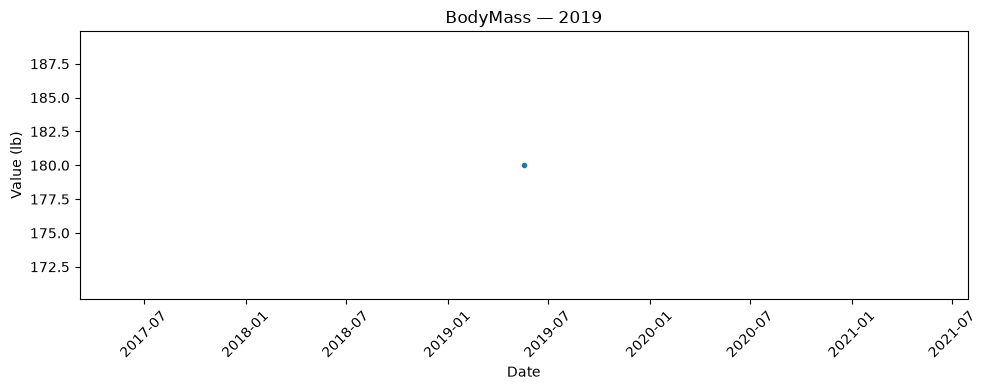

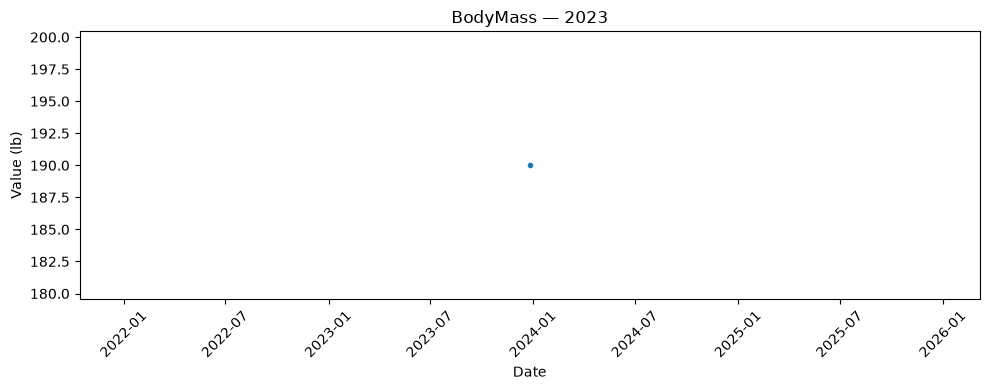

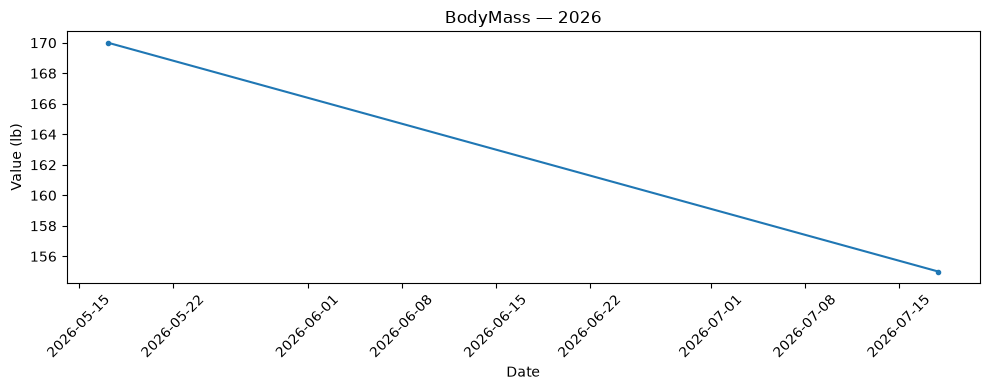

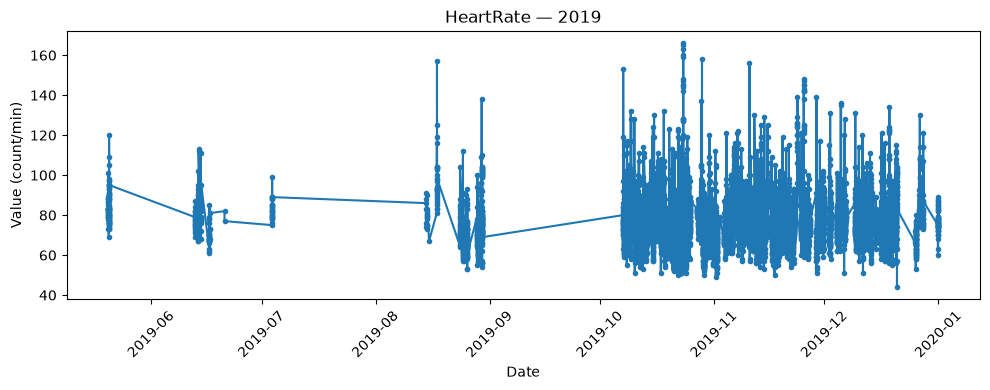

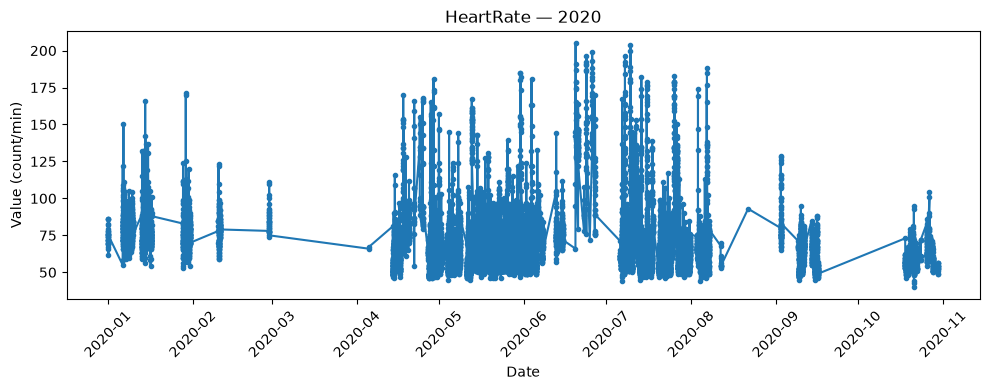

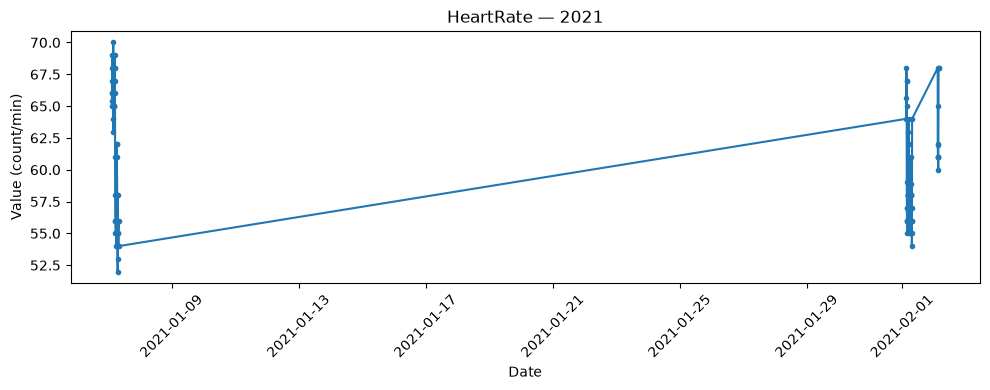

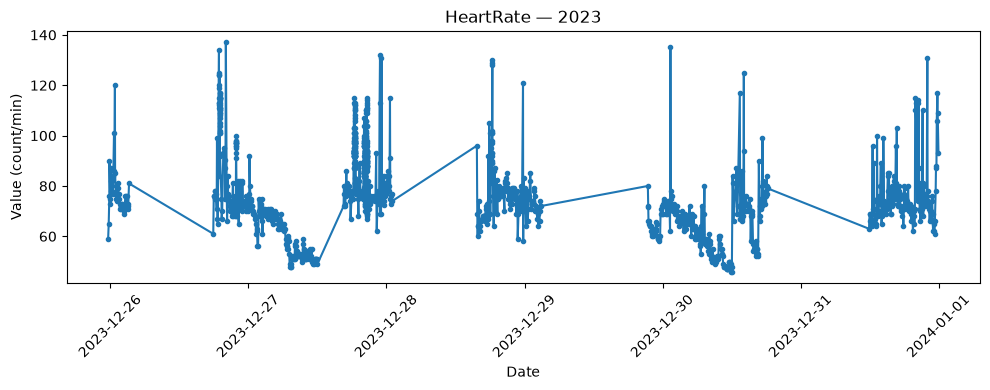

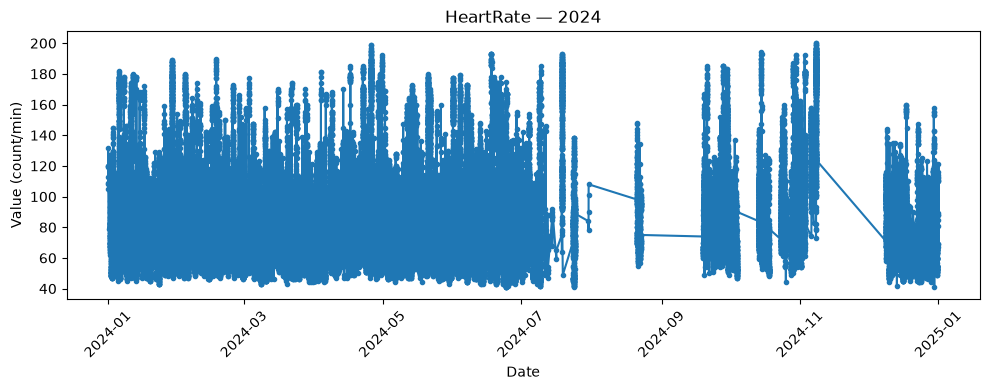

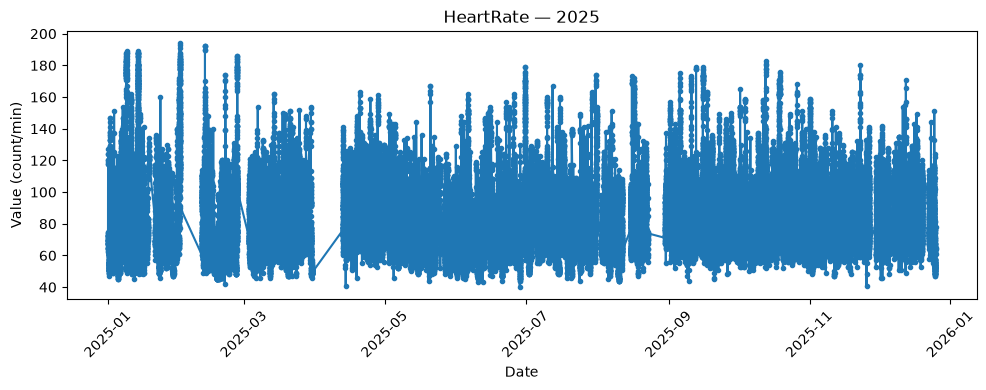

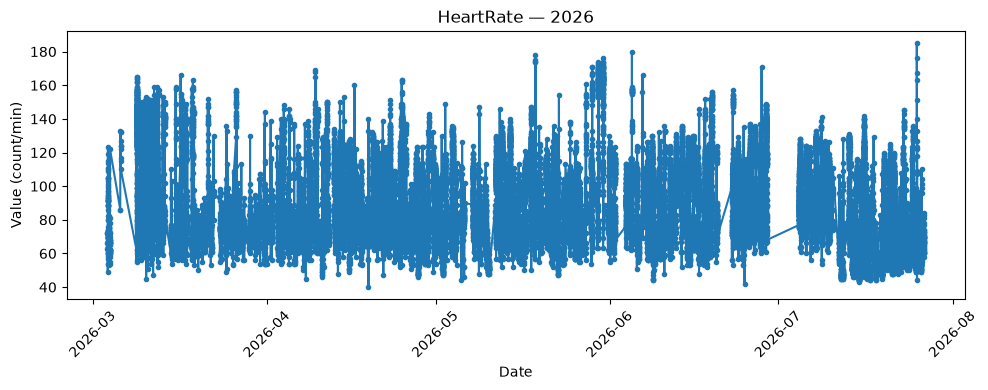

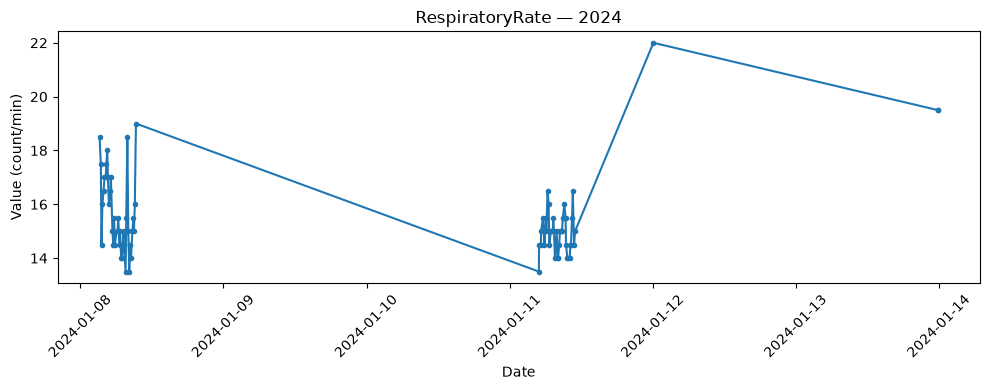

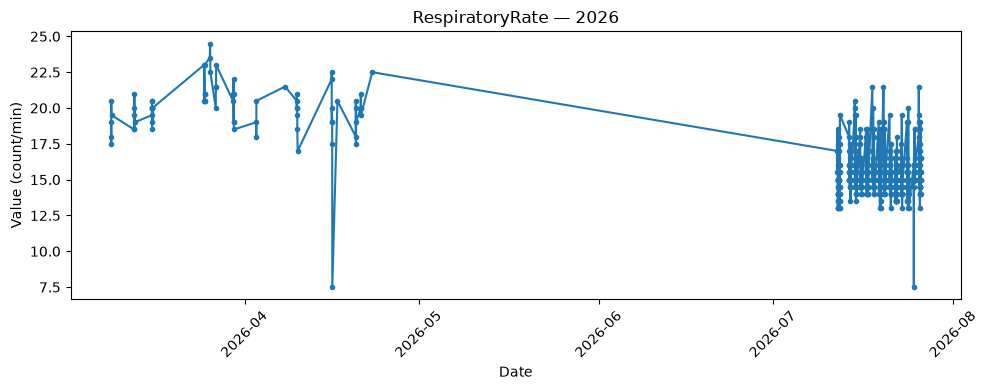

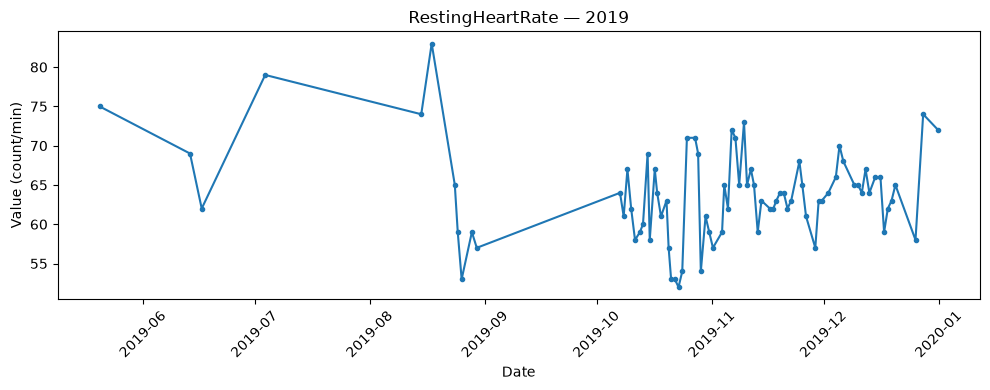

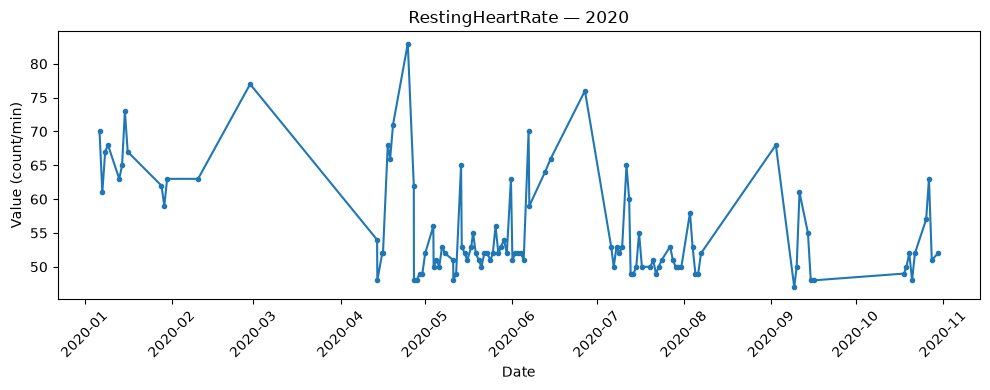

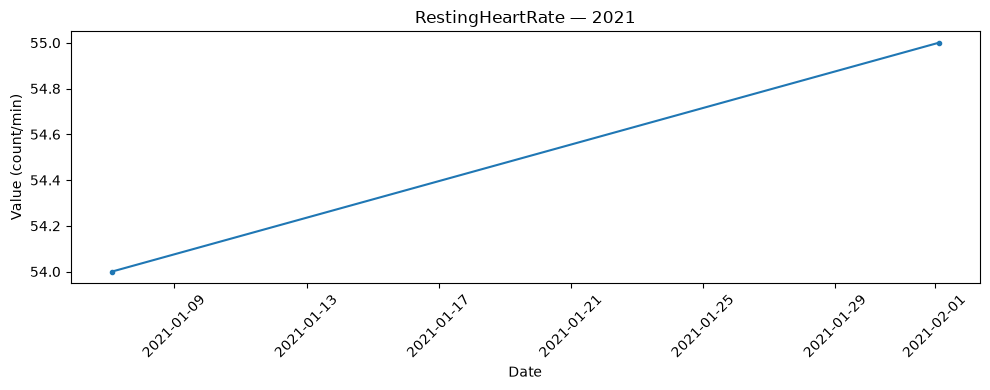

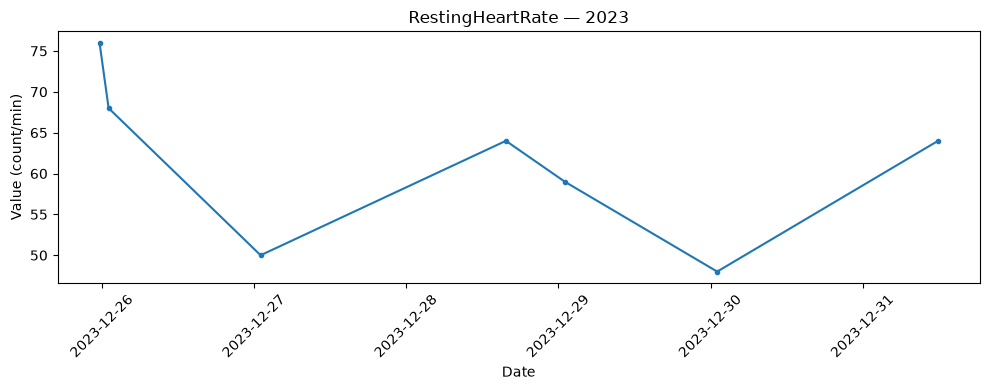

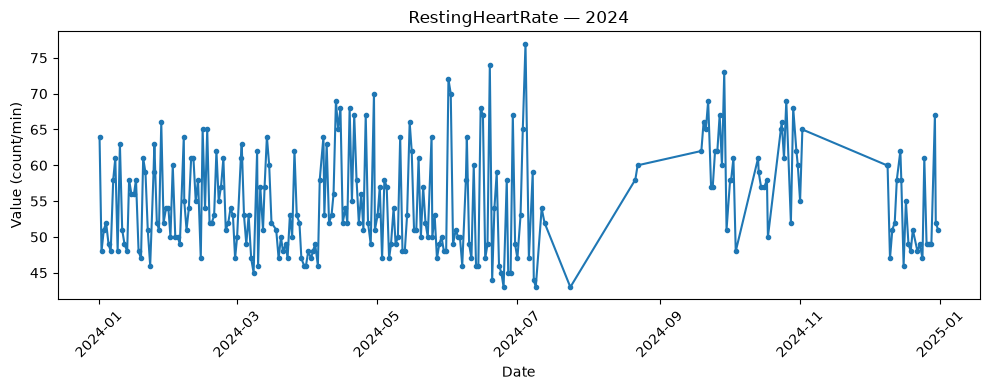

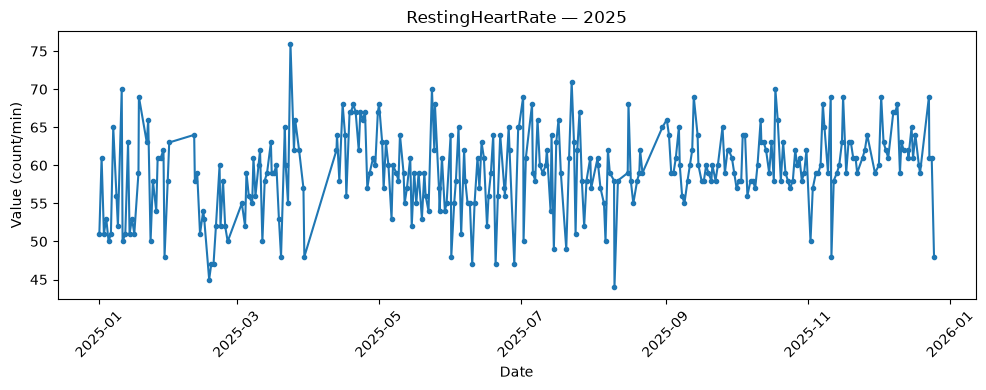

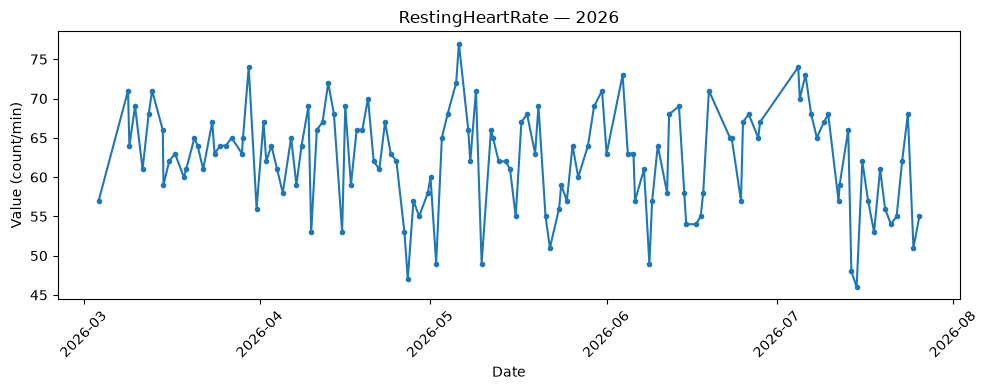

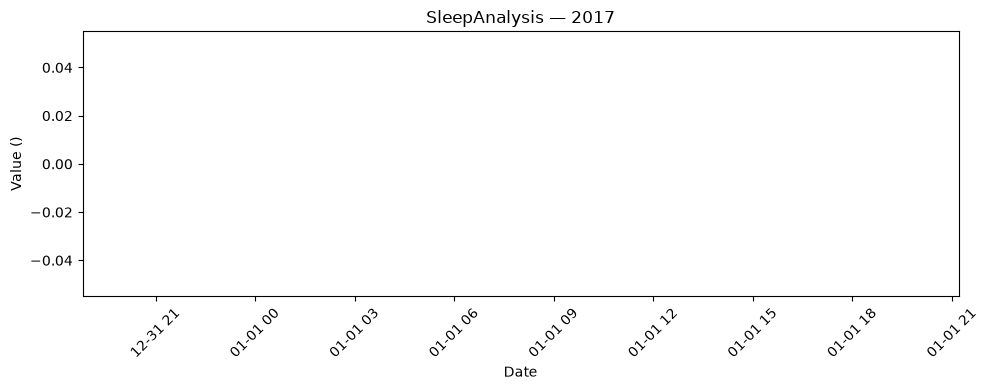

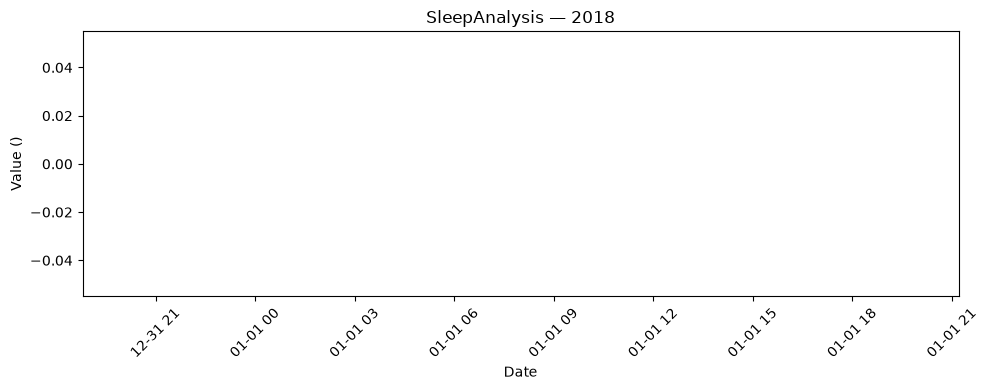

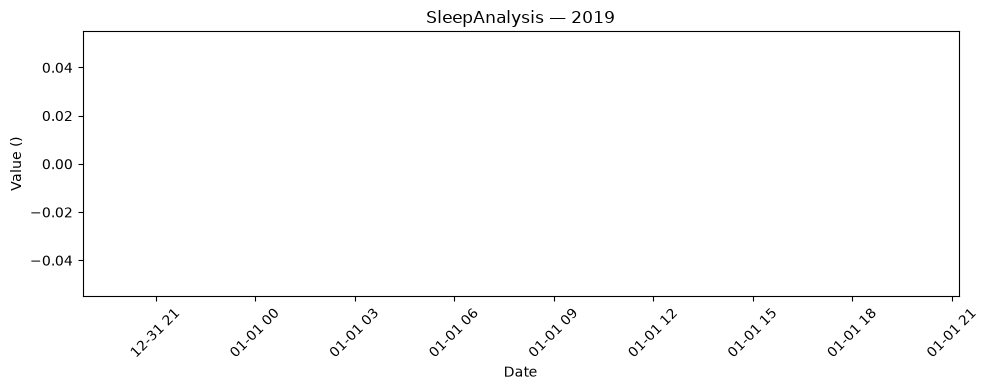

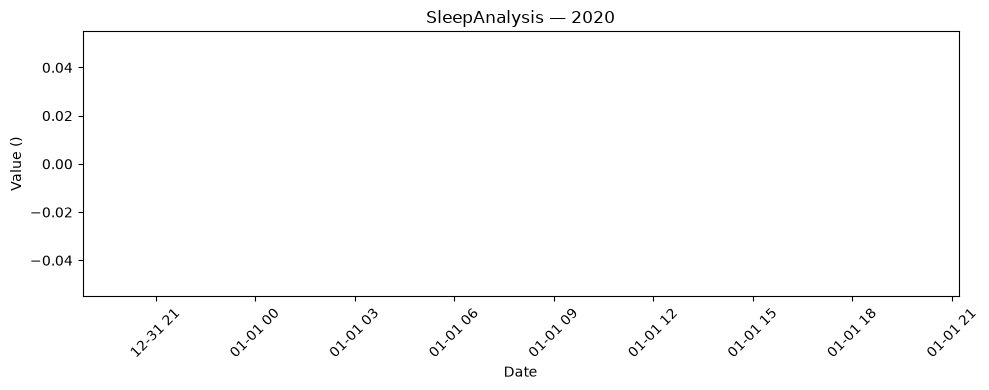

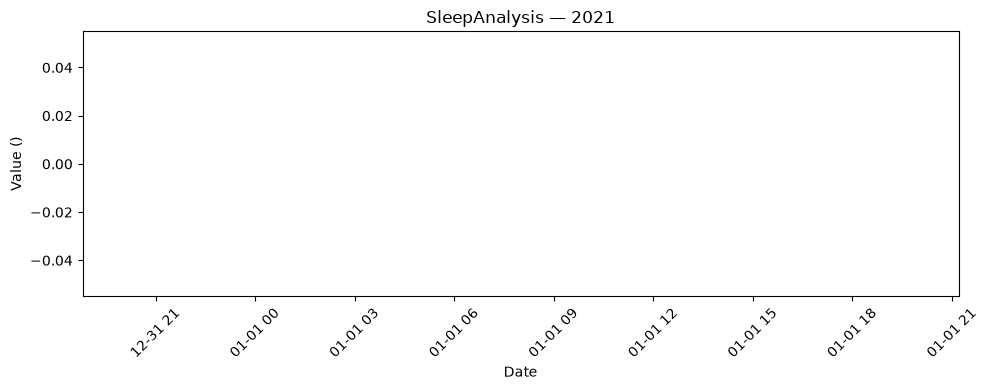

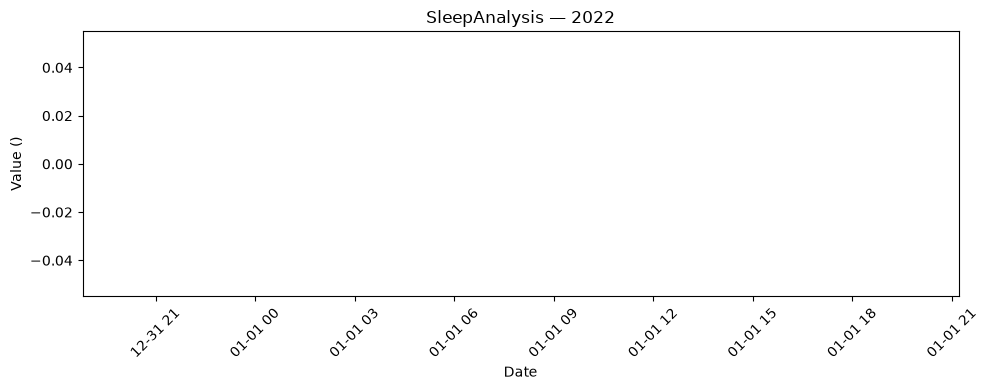

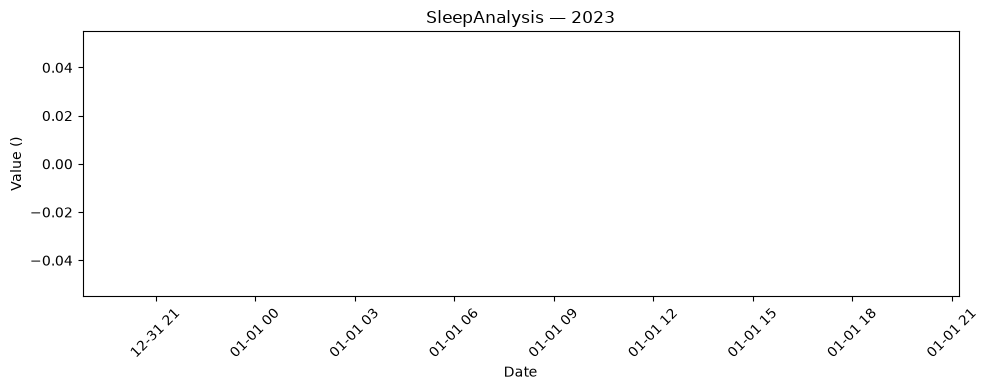

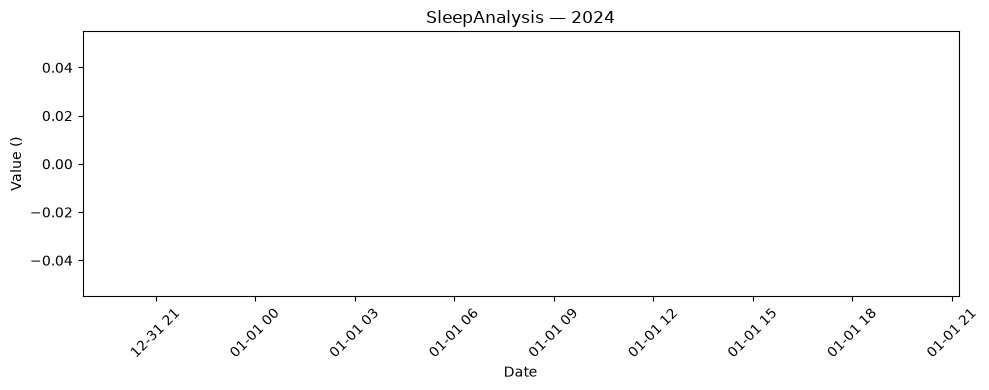

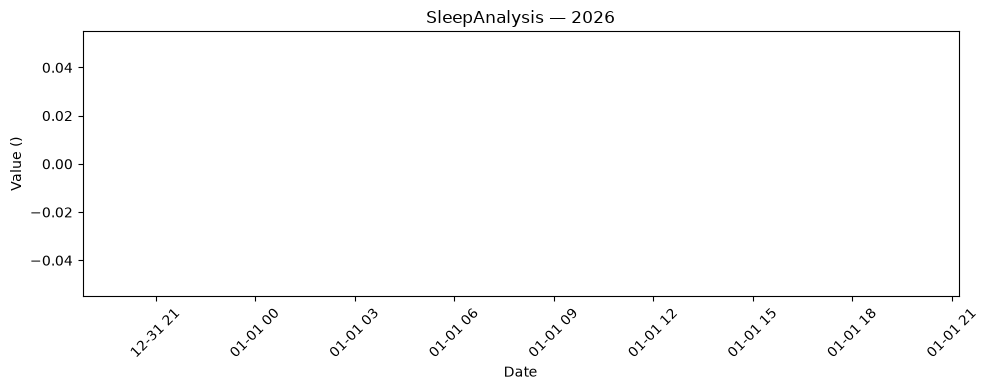

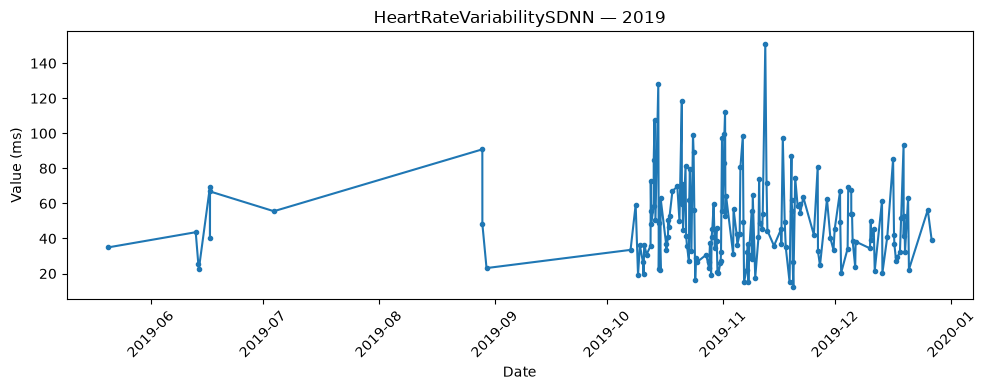

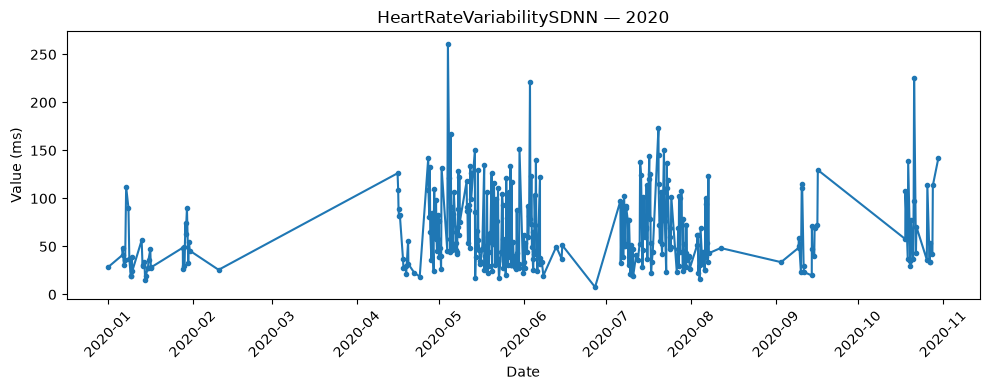

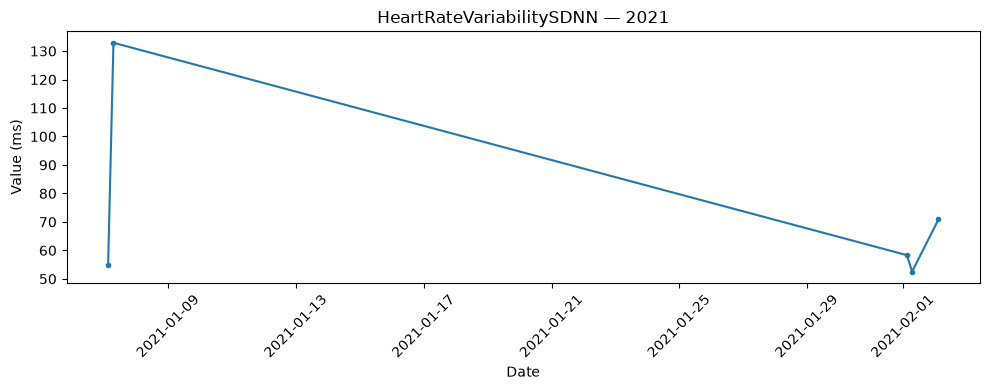

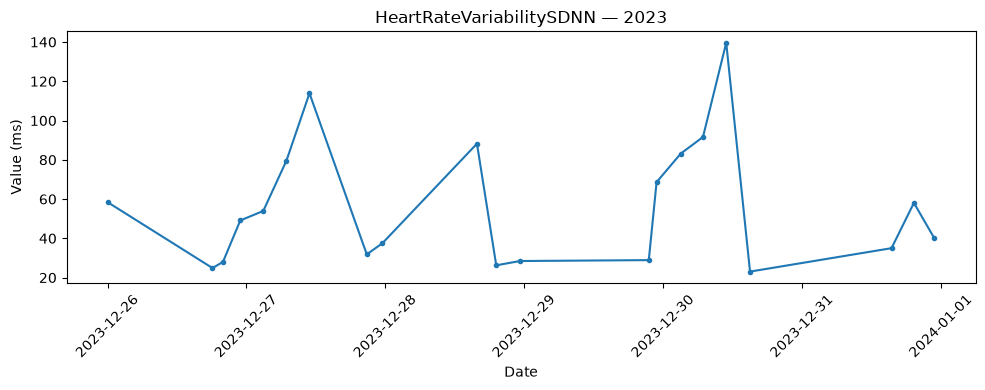

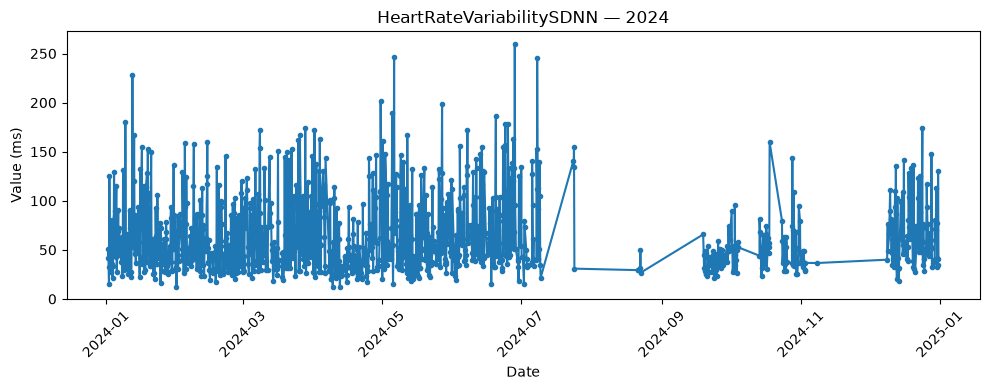

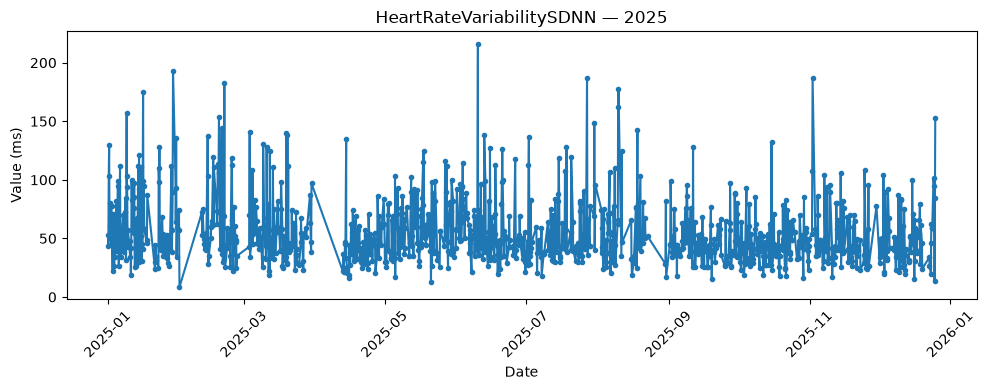

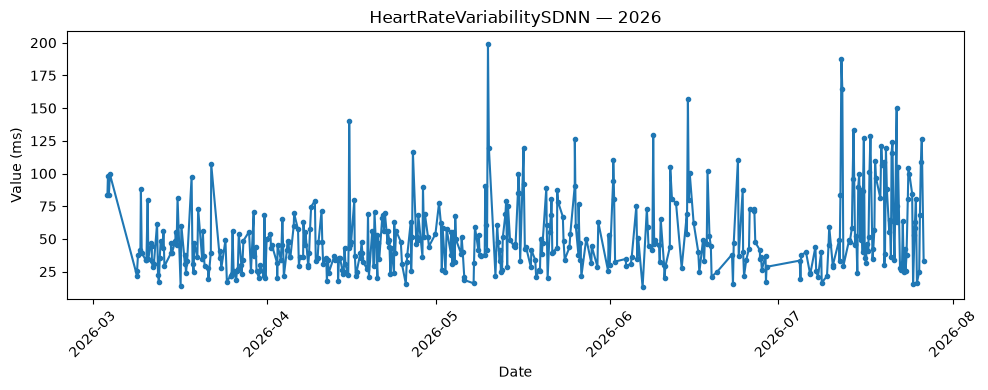

In [8]:
import matplotlib.pyplot as plt

for rtype in df["type"].unique():
    type_df = df[df["type"] == rtype]

    for year in sorted(type_df["year"].dropna().unique()):
        year_df = type_df[type_df["year"] == year].sort_values("startDate")

        if year_df.empty:
            continue

        plt.figure(figsize=(10, 4))
        plt.plot(year_df["startDate"], year_df["value"], marker="o", linestyle="-", markersize=3)
        plt.title(f"{rtype} — {int(year)}")
        plt.xlabel("Date")
        plt.ylabel(f"Value ({year_df['unit'].iloc[0] if year_df['unit'].notna().any() else ''})")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## Step 7: Save to CSV/Parquet for fast reloading later

Once you've parsed the huge XML once, save the result so you never have to re-parse it from scratch.

In [ ]:
# df.to_parquet("health_records.parquet", index=False)
df.to_csv("health_records.csv", index=False)  # alternative, larger file, slower to reload
print("Saved.")

Saved.
